# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Muhammad Naufal
- Email: naufalkz04@gmail.com
- Id Dicoding: muhammad_naufal_1603

## Persiapan

### Menyiapkan library yang dibutuhkan

In [214]:
import numpy as np 
import math
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

### Menyiapkan data yang akan diguankan

In [215]:
df = pd.read_csv('data.csv', sep=';')

## Data Understanding

In [216]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [217]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   int64  
 10 

In [218]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application_mode,4424.0,NaN,NaN,NaN,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application_order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime_evening_attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous_qualification,4424.0,NaN,NaN,NaN,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous_qualification_grade,4424.0,NaN,NaN,NaN,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,NaN,NaN,NaN,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mothers_qualification,4424.0,NaN,NaN,NaN,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Fathers_qualification,4424.0,NaN,NaN,NaN,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


In [219]:
df.isna().sum().sort_values(ascending=False)

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


In [220]:
print(f"Jumlah duplikasi: {df.duplicated().sum()}")

Jumlah duplikasi: 0


In [221]:
print("\nDistribusi nilai unik di setiap kolom")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Distribusi nilai unik di setiap kolom
Marital_status: 6 unique values
Application_mode: 18 unique values
Application_order: 8 unique values
Course: 17 unique values
Daytime_evening_attendance: 2 unique values
Previous_qualification: 17 unique values
Previous_qualification_grade: 101 unique values
Nacionality: 21 unique values
Mothers_qualification: 29 unique values
Fathers_qualification: 34 unique values
Mothers_occupation: 32 unique values
Fathers_occupation: 46 unique values
Admission_grade: 620 unique values
Displaced: 2 unique values
Educational_special_needs: 2 unique values
Debtor: 2 unique values
Tuition_fees_up_to_date: 2 unique values
Gender: 2 unique values
Scholarship_holder: 2 unique values
Age_at_enrollment: 46 unique values
International: 2 unique values
Curricular_units_1st_sem_credited: 21 unique values
Curricular_units_1st_sem_enrolled: 23 unique values
Curricular_units_1st_sem_evaluations: 35 unique values
Curricular_units_1st_sem_approved: 23 unique values
Curricula

In [222]:
print(df['Status'].value_counts())

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [223]:
df = df[df['Status'].isin(['Dropout', 'Graduate'])]
df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [224]:
print(df['Status'].value_counts())

Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64


In [225]:
num_cols = [
    'Application_order', 'Previous_qualification_grade', 'Admission_grade',
    'Age_at_enrollment', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
    'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP'
]
df[num_cols].describe()

,Application_order,Previous_qualification_grade,Admission_grade,Age_at_enrollment,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,1.750138,132.920606,127.293939,23.461157,0.754270,6.337466,8.071074,4.791460,10.534860,0.128926,0.581818,6.296419,7.763085,4.518457,10.036155,0.142149,11.630358,1.231598,-0.009256
std,1.333831,13.238373,14.611295,7.827994,2.477277,2.570773,4.286632,3.237845,5.057694,0.679111,2.022688,2.263020,3.964163,3.162376,5.481742,0.747670,2.667652,1.384911,2.259986
min,0.000000,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,125.000000,118.000000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.517857,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,133.100000,126.500000,20.000000,0.000000,6.000000,8.000000,5.000000,12.341429,0.000000,0.000000,6.000000,8.000000,5.000000,12.333333,0.000000,11.100000,1.400000,0.320000
75%,2.000000,140.000000,135.100000,25.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,13.900000,2.600000,1.790000
max,6.000000,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [226]:
cat_cols = [
    'Marital_status', 'Application_mode', 
    'Course', 'Daytime_evening_attendance', 'Previous_qualification',
    'Nacionality', 'Mothers_qualification', 'Fathers_qualification',
    'Mothers_occupation', 'Fathers_occupation', 'Displaced',
    'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date',
    'Gender', 'Scholarship_holder', 'International',
    'Status'
]
df[cat_cols].astype(object).describe()

,Marital_status,Application_mode,Course,Daytime_evening_attendance,Previous_qualification,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,International,Status
count,3630,3630,3630,3630,3630,3630,3630,3630,3630,3630,3630,3630,3630,3630,3630,3630,3630,3630
unique,6,18,17,2,17,19,29,34,29,42,2,2,2,2,2,2,2,2
top,1,1,9500,1,1,1,1,37,9,9,1,0,0,1,0,0,0,Graduate
freq,3199,1408,666,3222,3019,3544,865,1010,1313,847,1993,3590,3217,3144,2381,2661,3544,2209


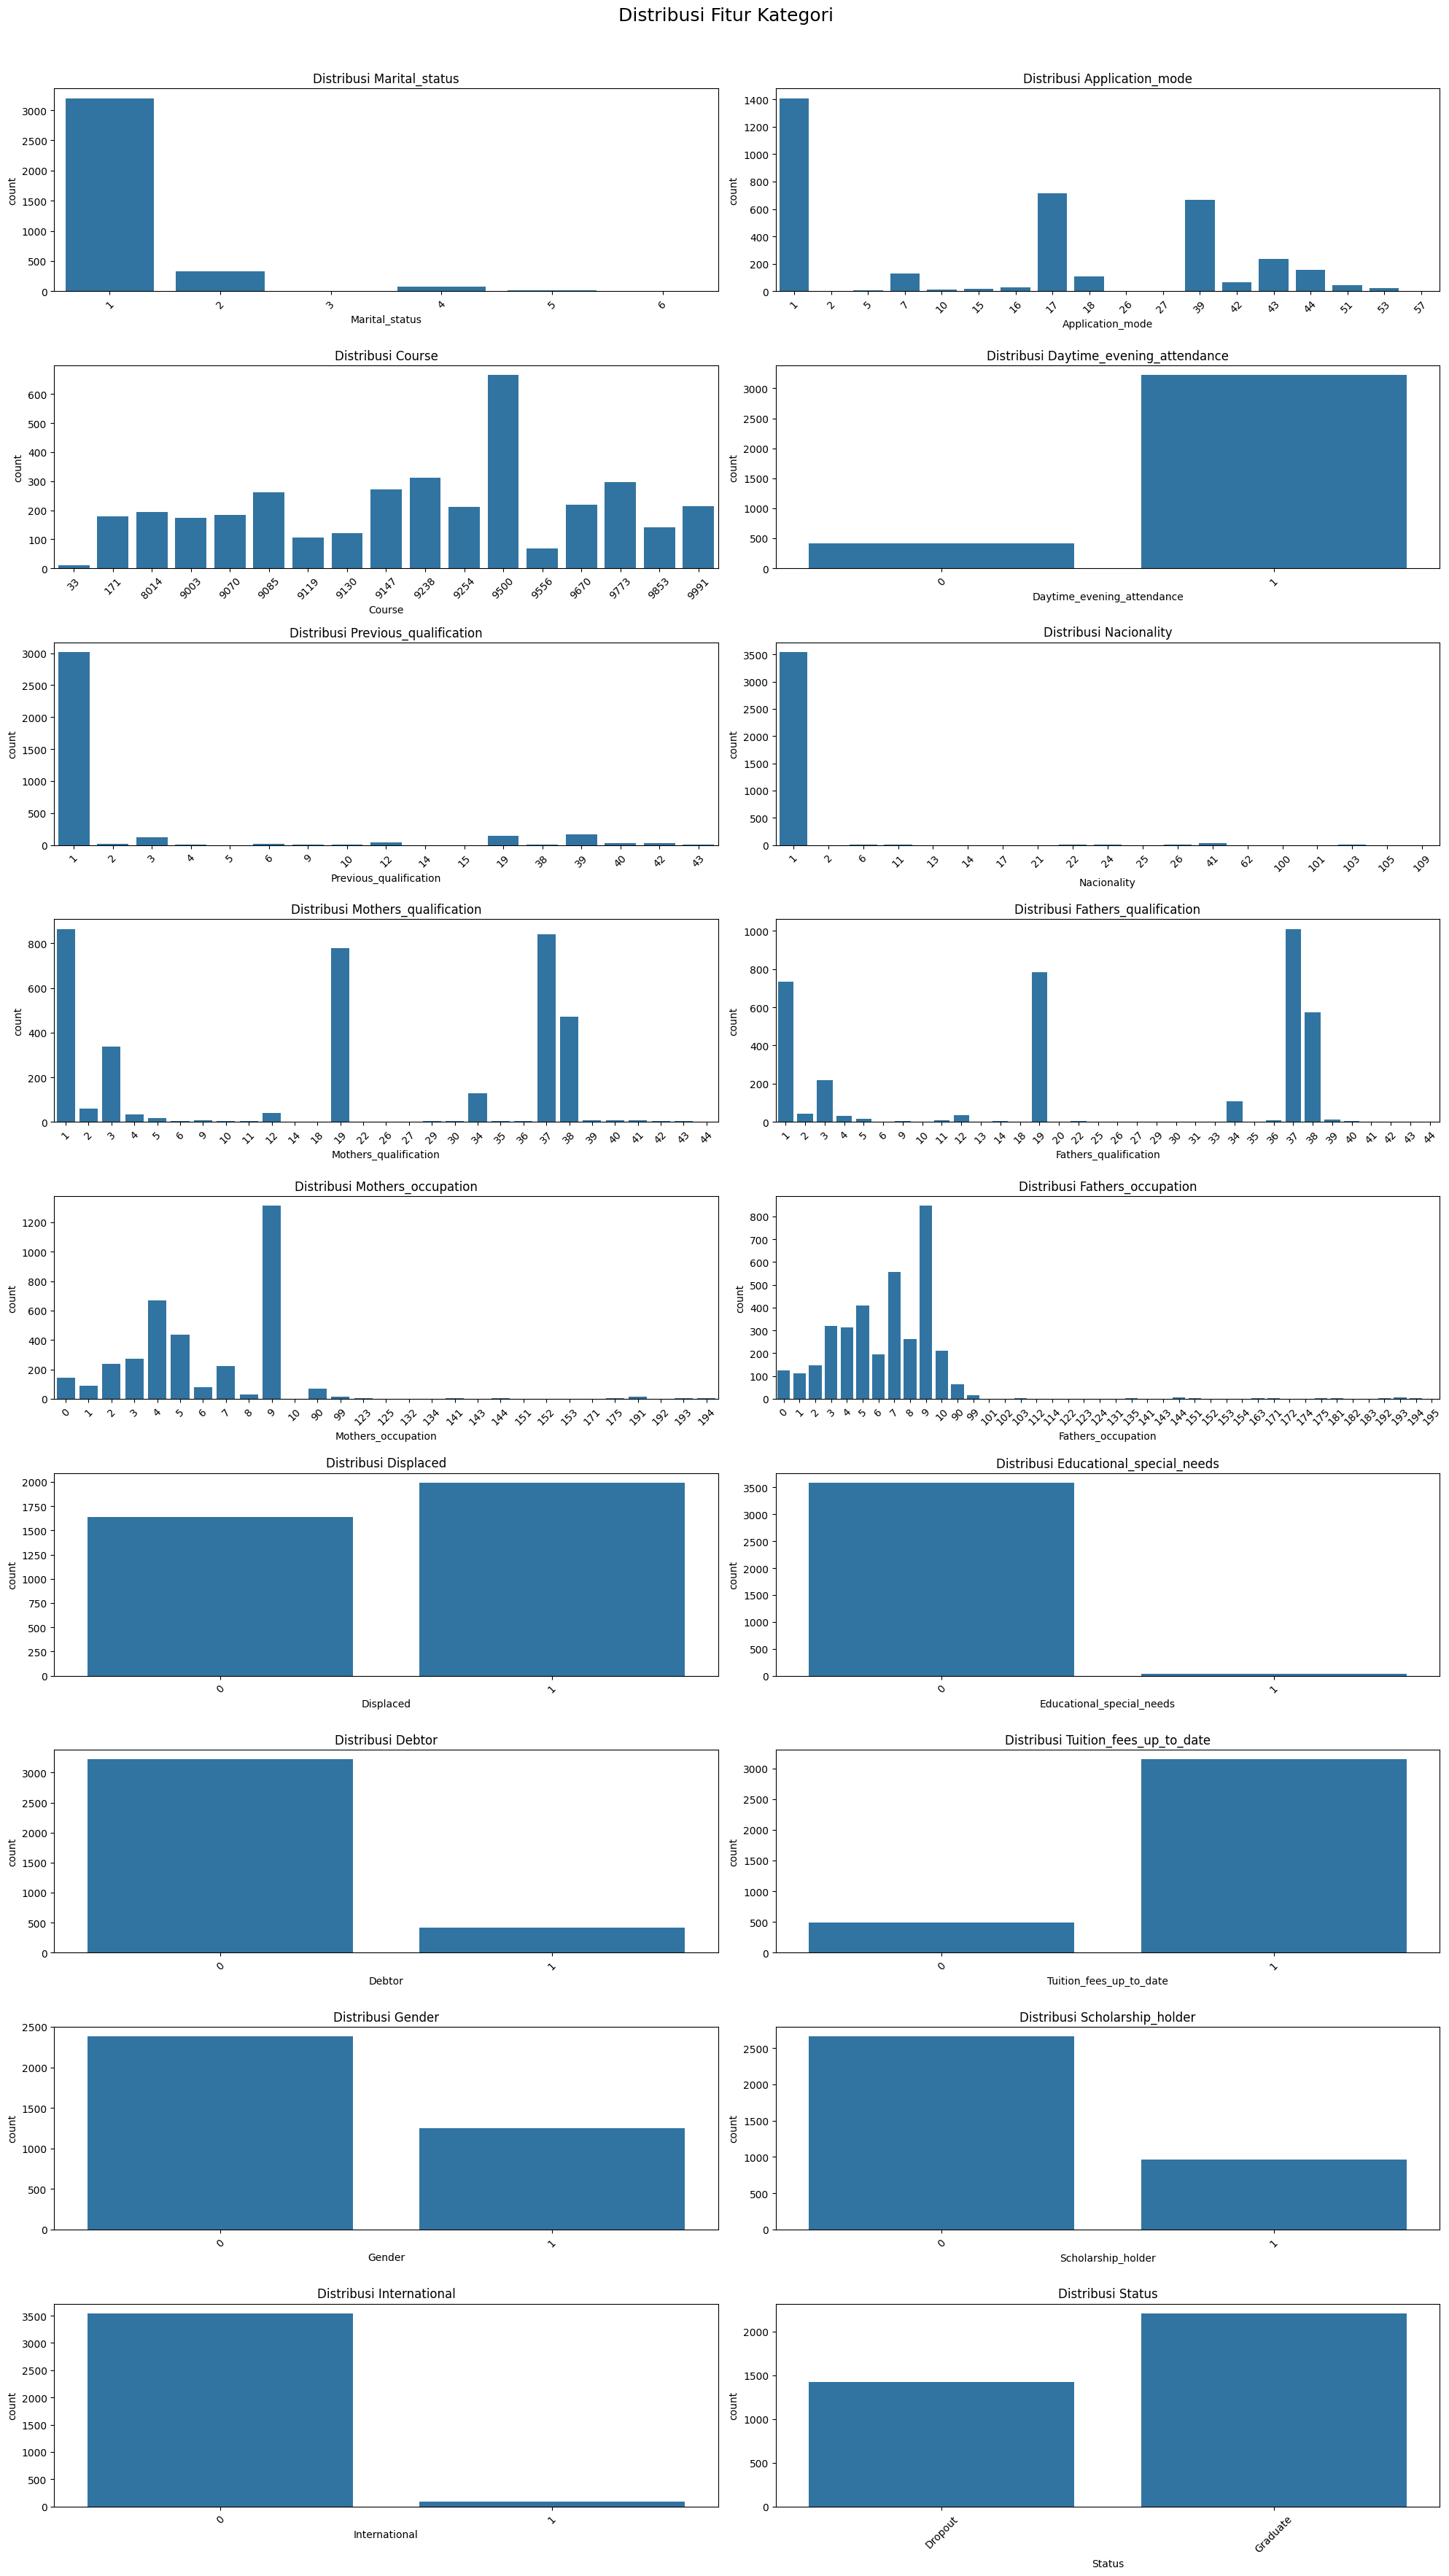

In [227]:
# Hitung jumlah baris dan kolom 
n_cols = 2 # jumlah kolom grafik
n_rows = math.ceil(len(cat_cols) / n_cols)

plt.figure(figsize=(20, n_rows * 4))
plt.suptitle("Distribusi Fitur Kategori", fontsize=18)

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Distribusi {col}")
    plt.xticks(rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.97]) # supaya title tidak tertimpa
plt.show()

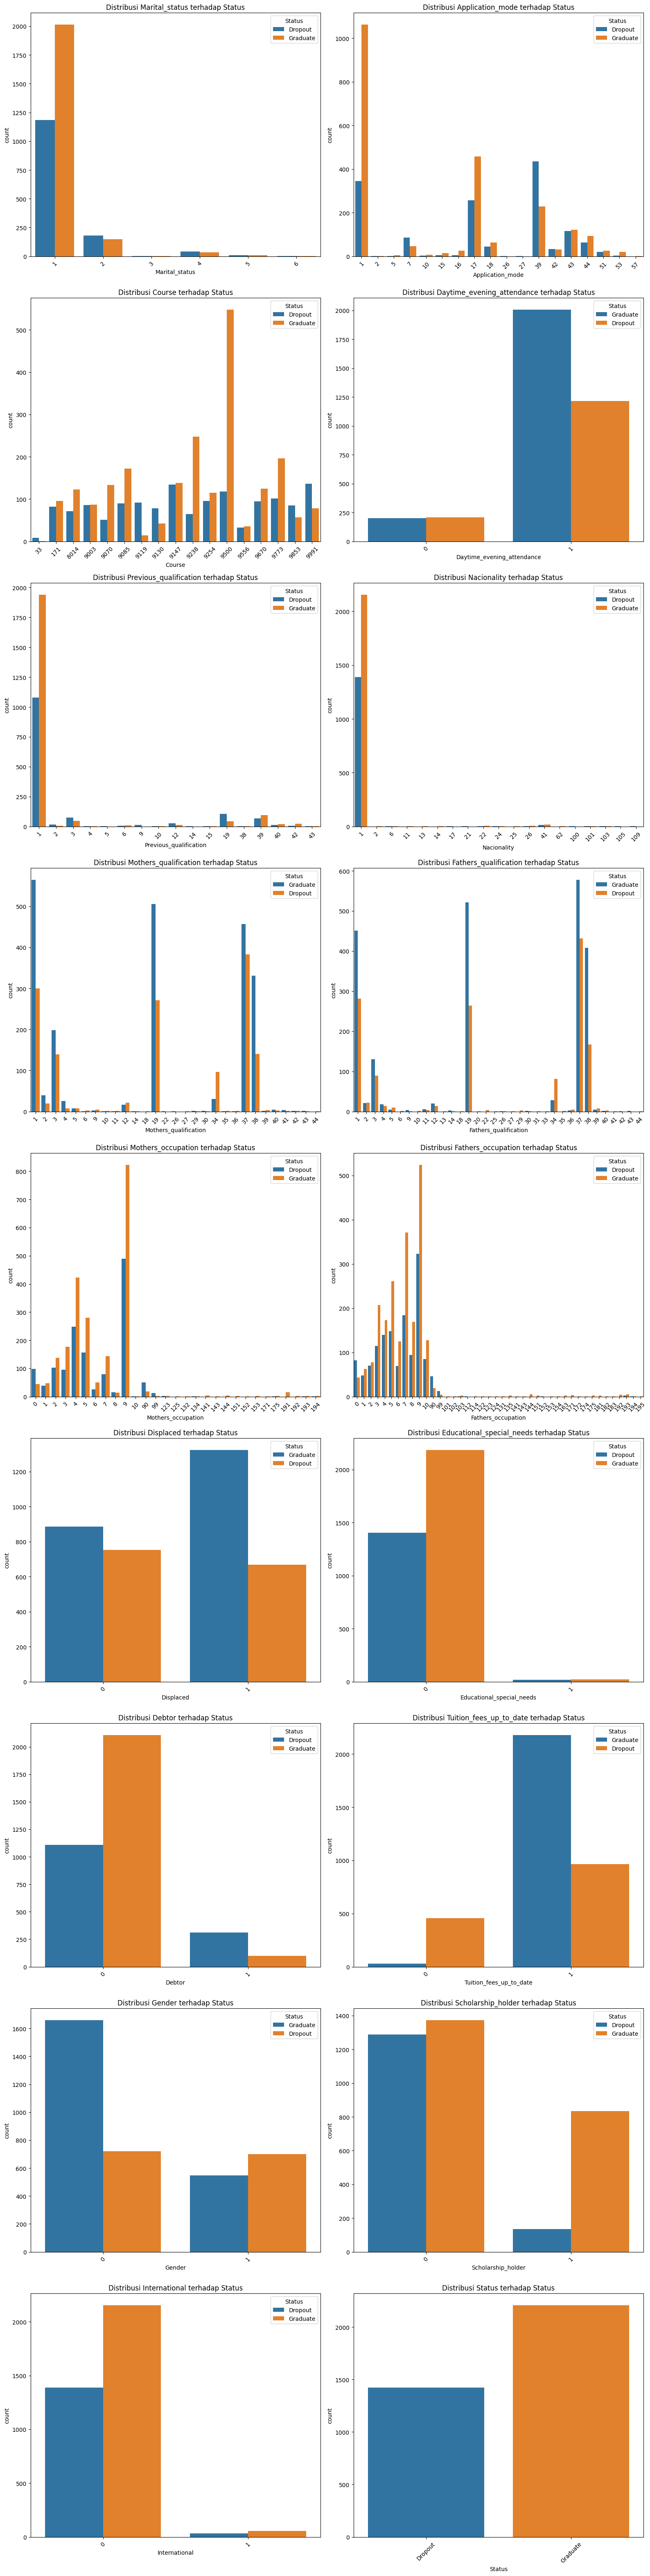

In [228]:
plt.figure(figsize=(16, len(cat_cols) * 3.5))

n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, x=col, hue='Status')
    plt.title(f"Distribusi {col} terhadap Status")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Figure size 2400x1600 with 0 Axes>

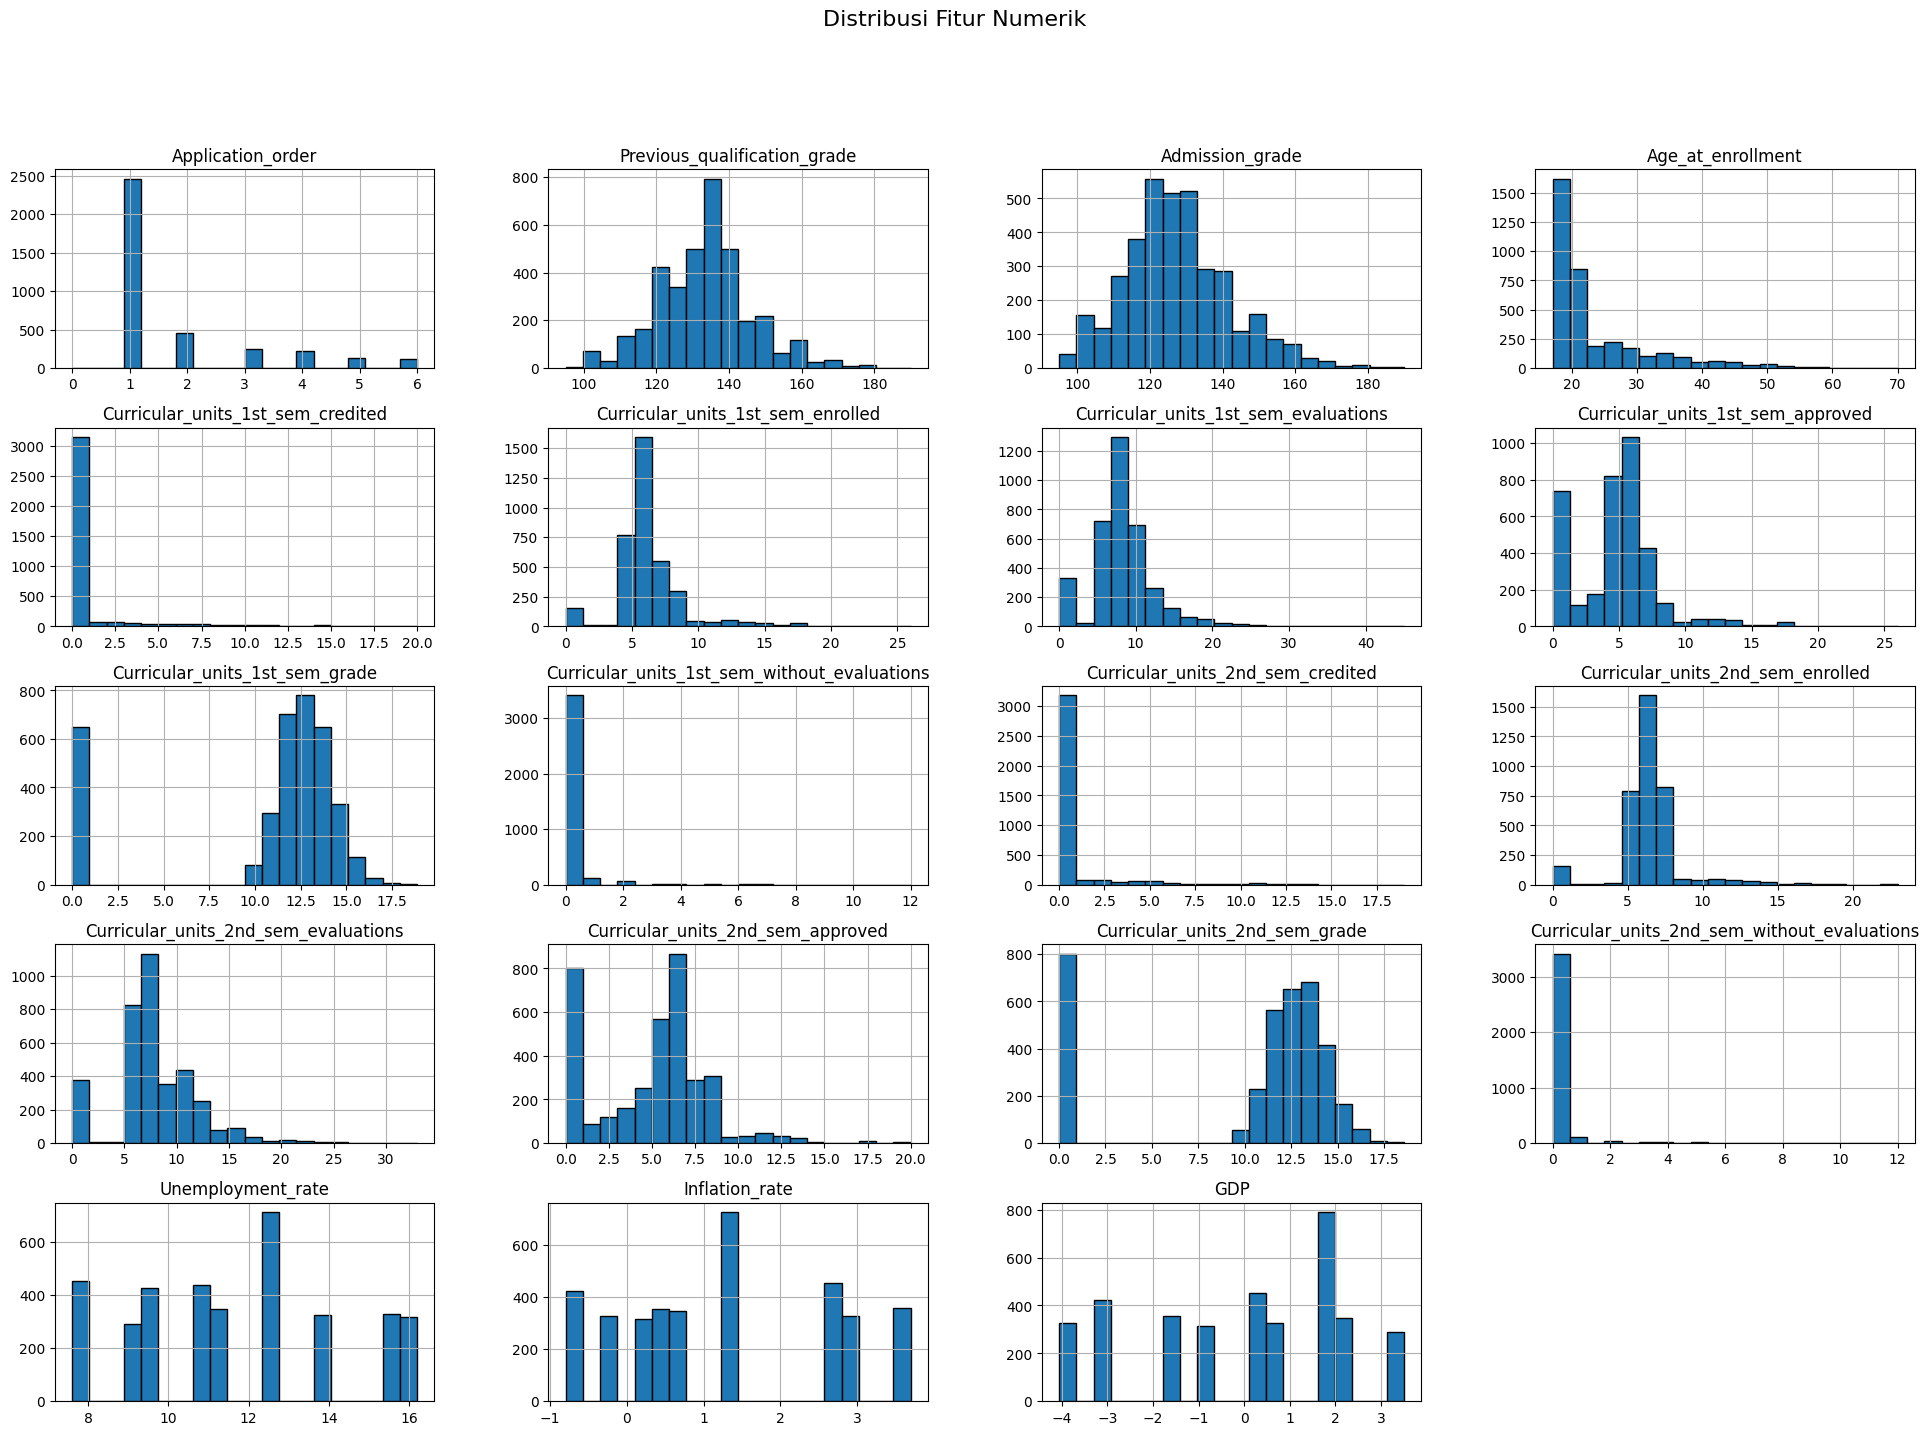

In [229]:
# Plot histogram untuk fitur numerik
plt.figure(figsize=(24, 16))
df[num_cols].hist(bins=20, figsize=(24, 16), edgecolor='black')
plt.suptitle("Distribusi Fitur Numerik", fontsize=16)
plt.show()

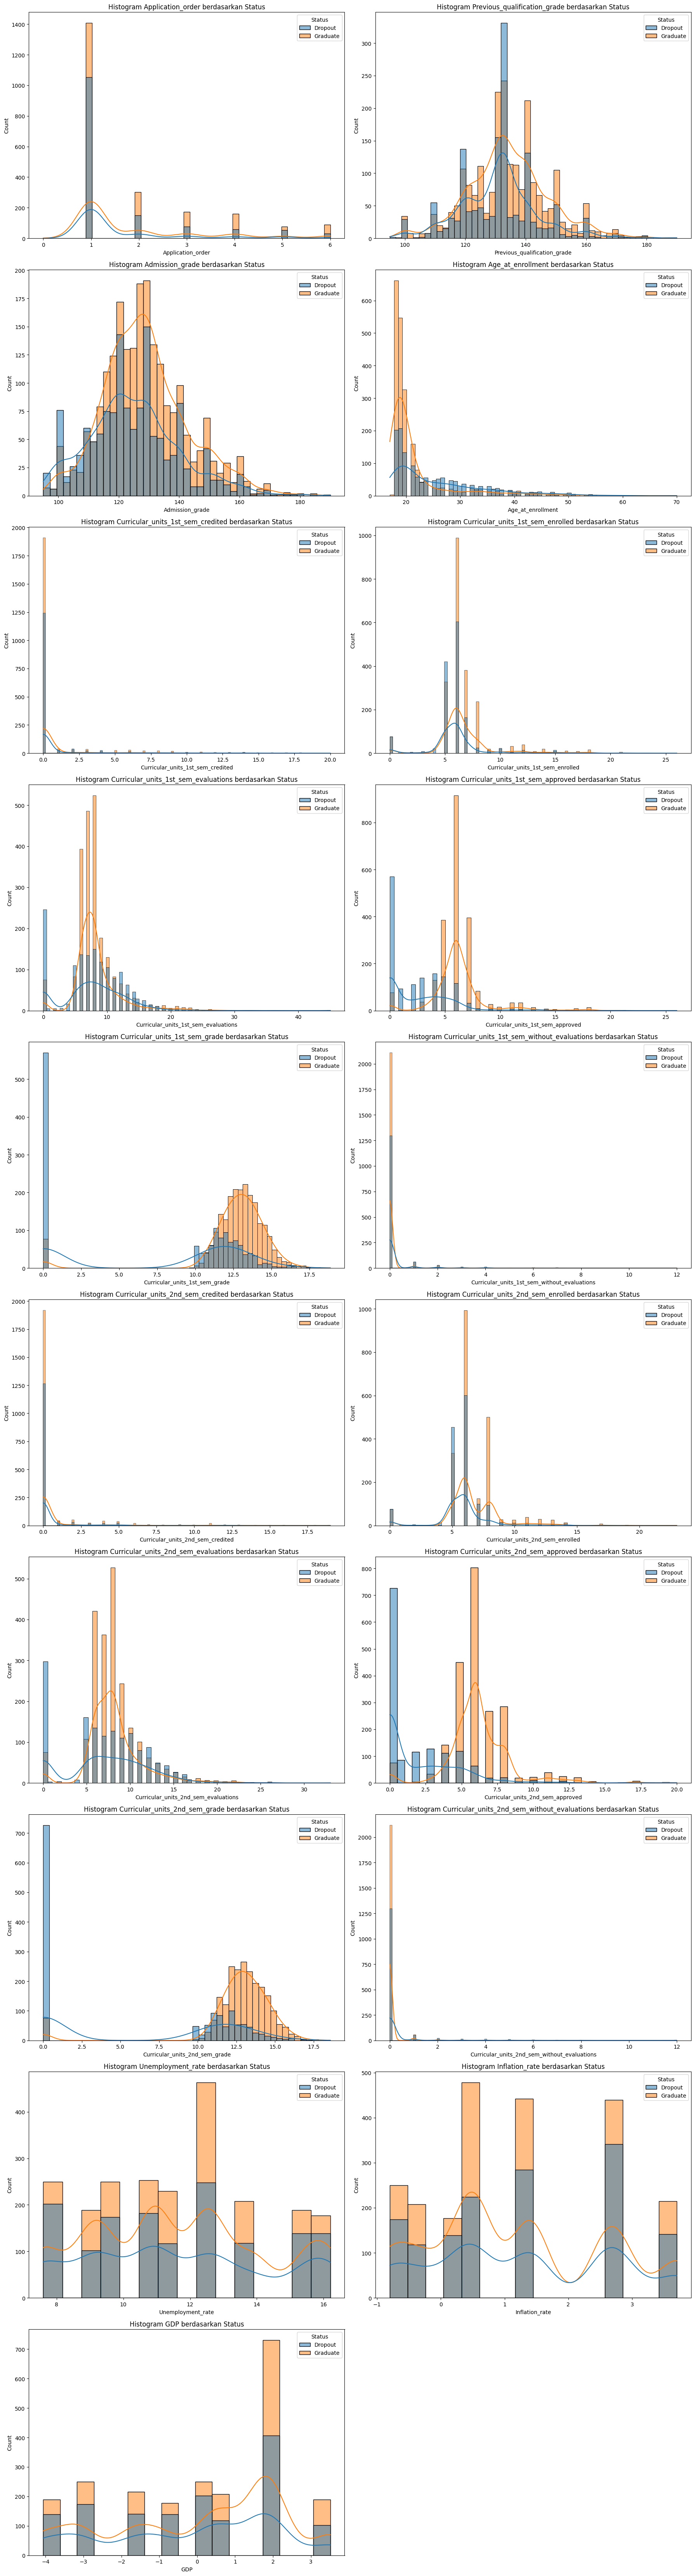

In [230]:
plt.figure(figsize=(18, len(num_cols) * 3.5))
n_rows = math.ceil(len(num_cols) / n_cols)
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=df, x=col, hue="Status", kde=True)
    plt.title(f"Histogram {col} berdasarkan Status")
    plt.xlabel(col)
    plt.ylabel("Count")
    
plt.tight_layout()
plt.show()

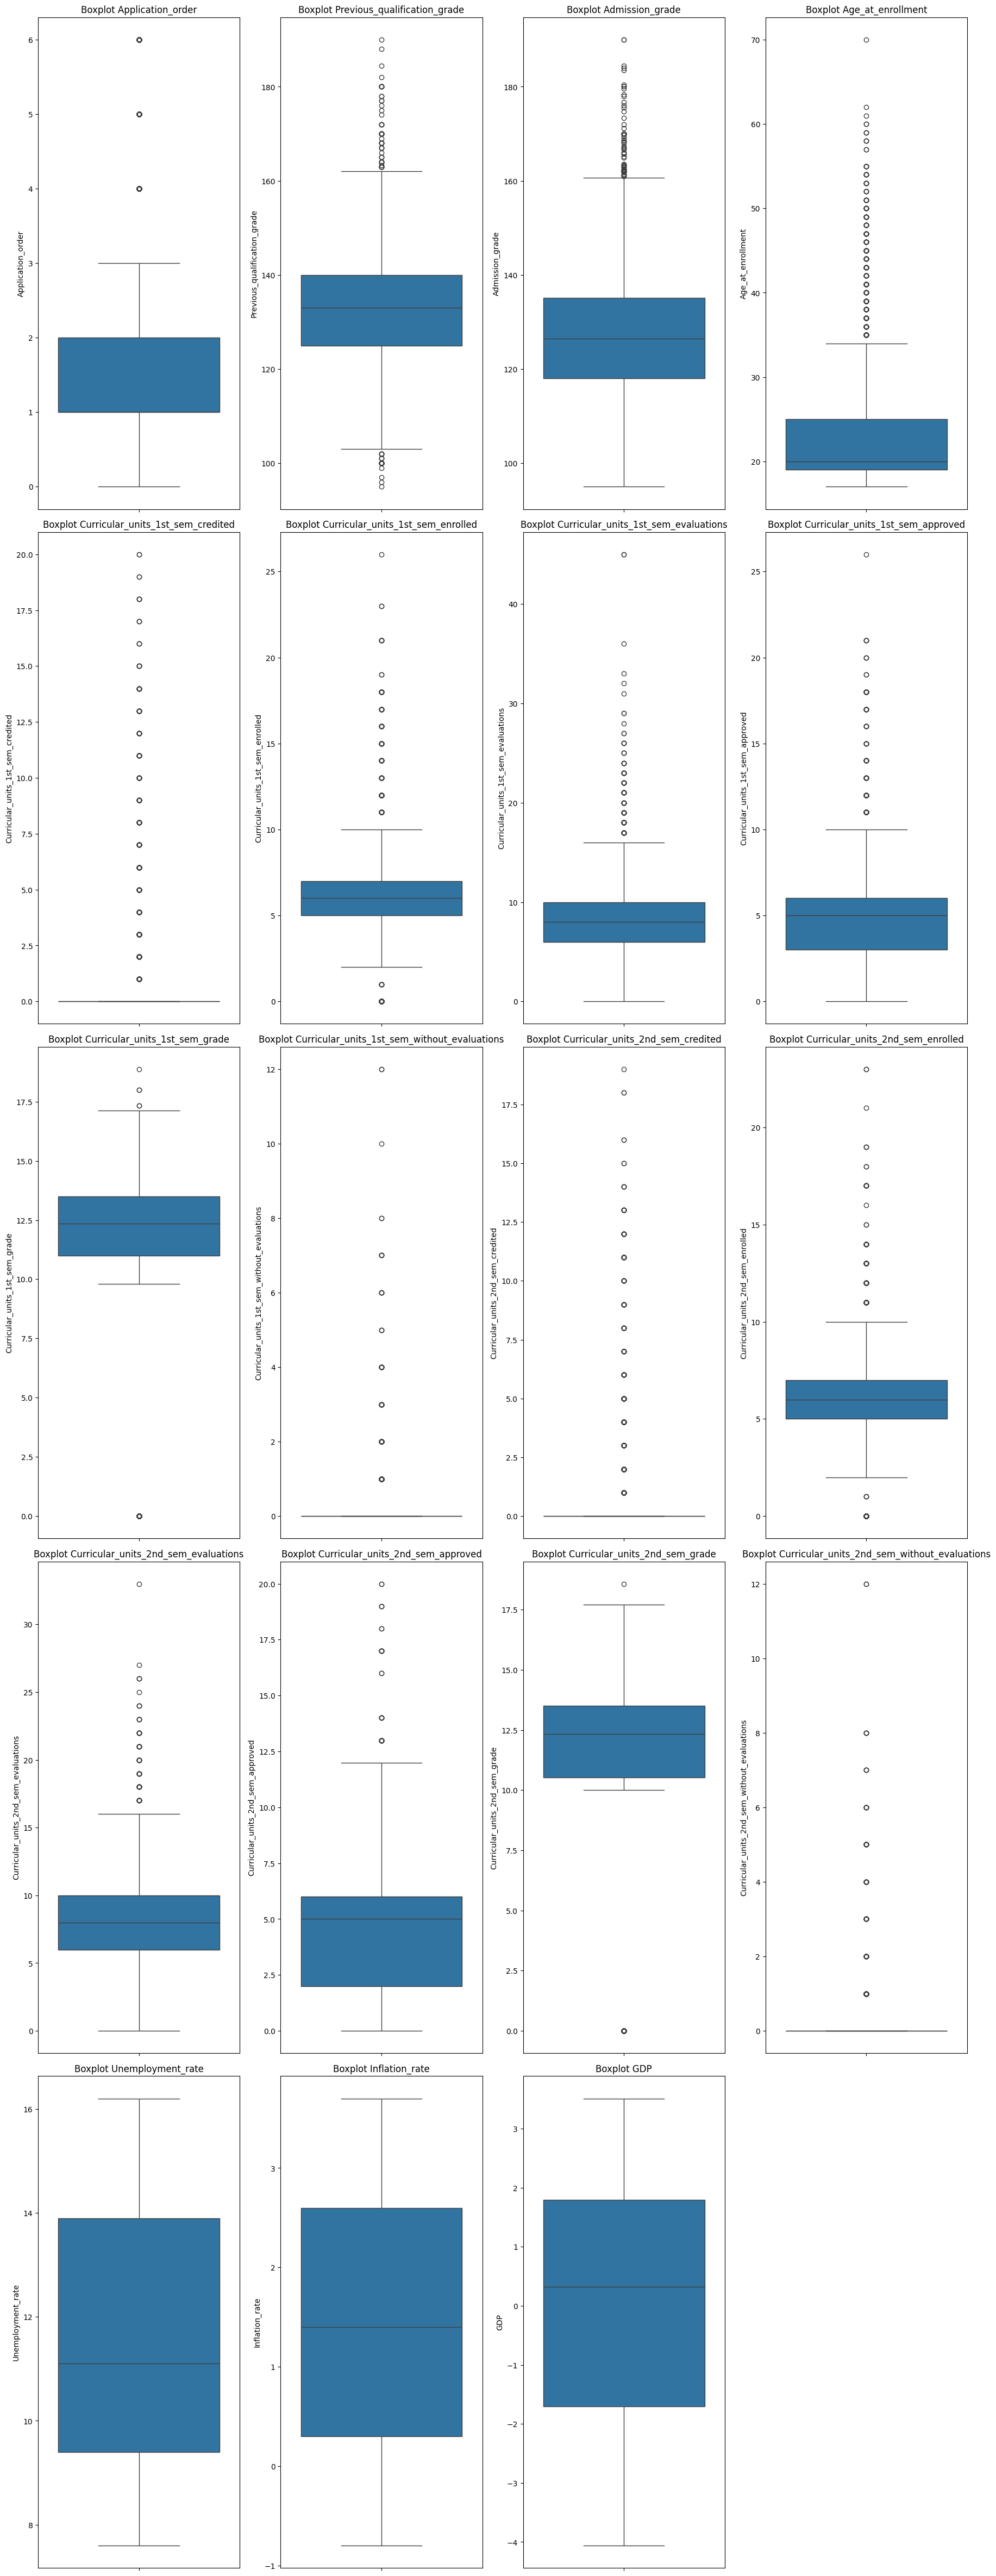

In [231]:
plt.figure(figsize=(18, len(num_cols) * 2.5))
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot {col}")
plt.tight_layout()
plt.show()

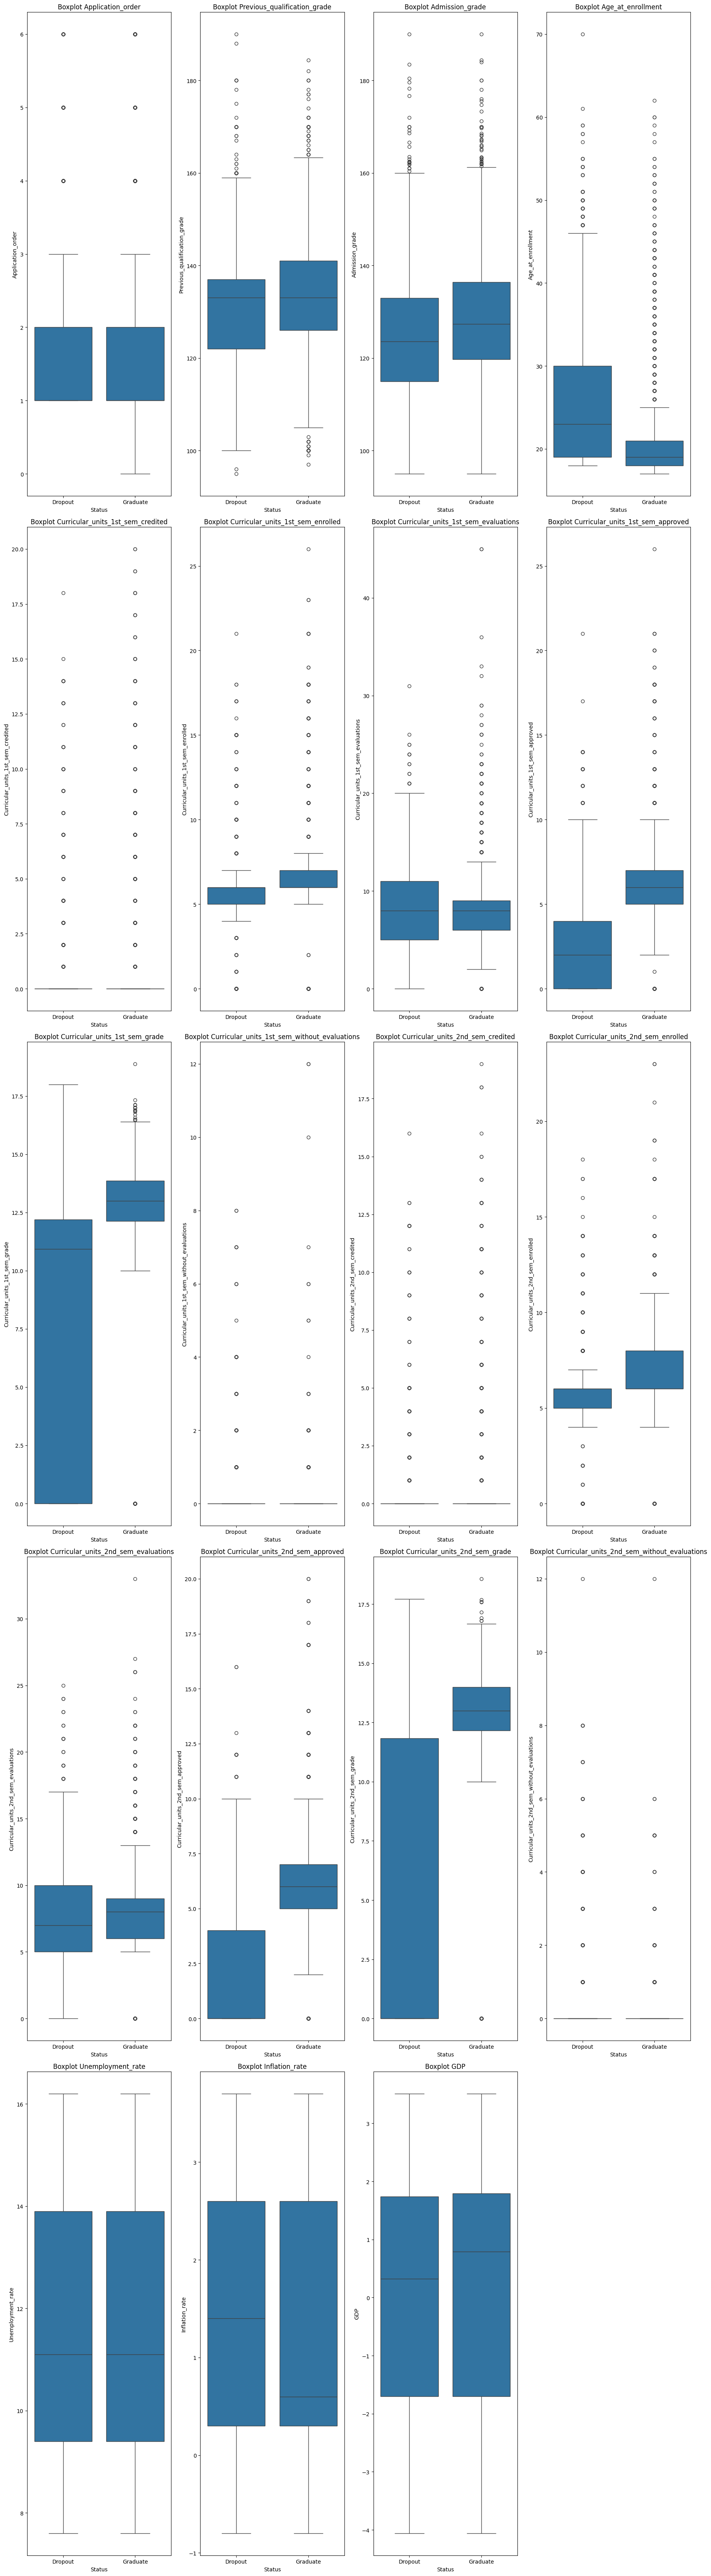

In [232]:
plt.figure(figsize=(18, len(num_cols) * 3.5))
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df["Status"], y=df[col])
    plt.title(f"Boxplot {col}")
plt.tight_layout()
plt.show()

In [233]:
# Deteksi outliers menggunakan IQR
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outlier = (
    (df[num_cols] < (Q1 - 1.5 * IQR)) |
    (df[num_cols] > (Q3 + 1.5 * IQR))
)
outlier.sum()

Application_order                               468
Previous_qualification_grade                    146
Admission_grade                                  71
Age_at_enrollment                               389
Curricular_units_1st_sem_credited               480
Curricular_units_1st_sem_enrolled               366
Curricular_units_1st_sem_evaluations            136
Curricular_units_1st_sem_approved               165
Curricular_units_1st_sem_grade                  652
Curricular_units_1st_sem_without_evaluations    224
Curricular_units_2nd_sem_credited               447
Curricular_units_2nd_sem_enrolled               321
Curricular_units_2nd_sem_evaluations             81
Curricular_units_2nd_sem_approved                44
Curricular_units_2nd_sem_grade                  803
Curricular_units_2nd_sem_without_evaluations    214
Unemployment_rate                                 0
Inflation_rate                                    0
GDP                                               0
dtype: int64

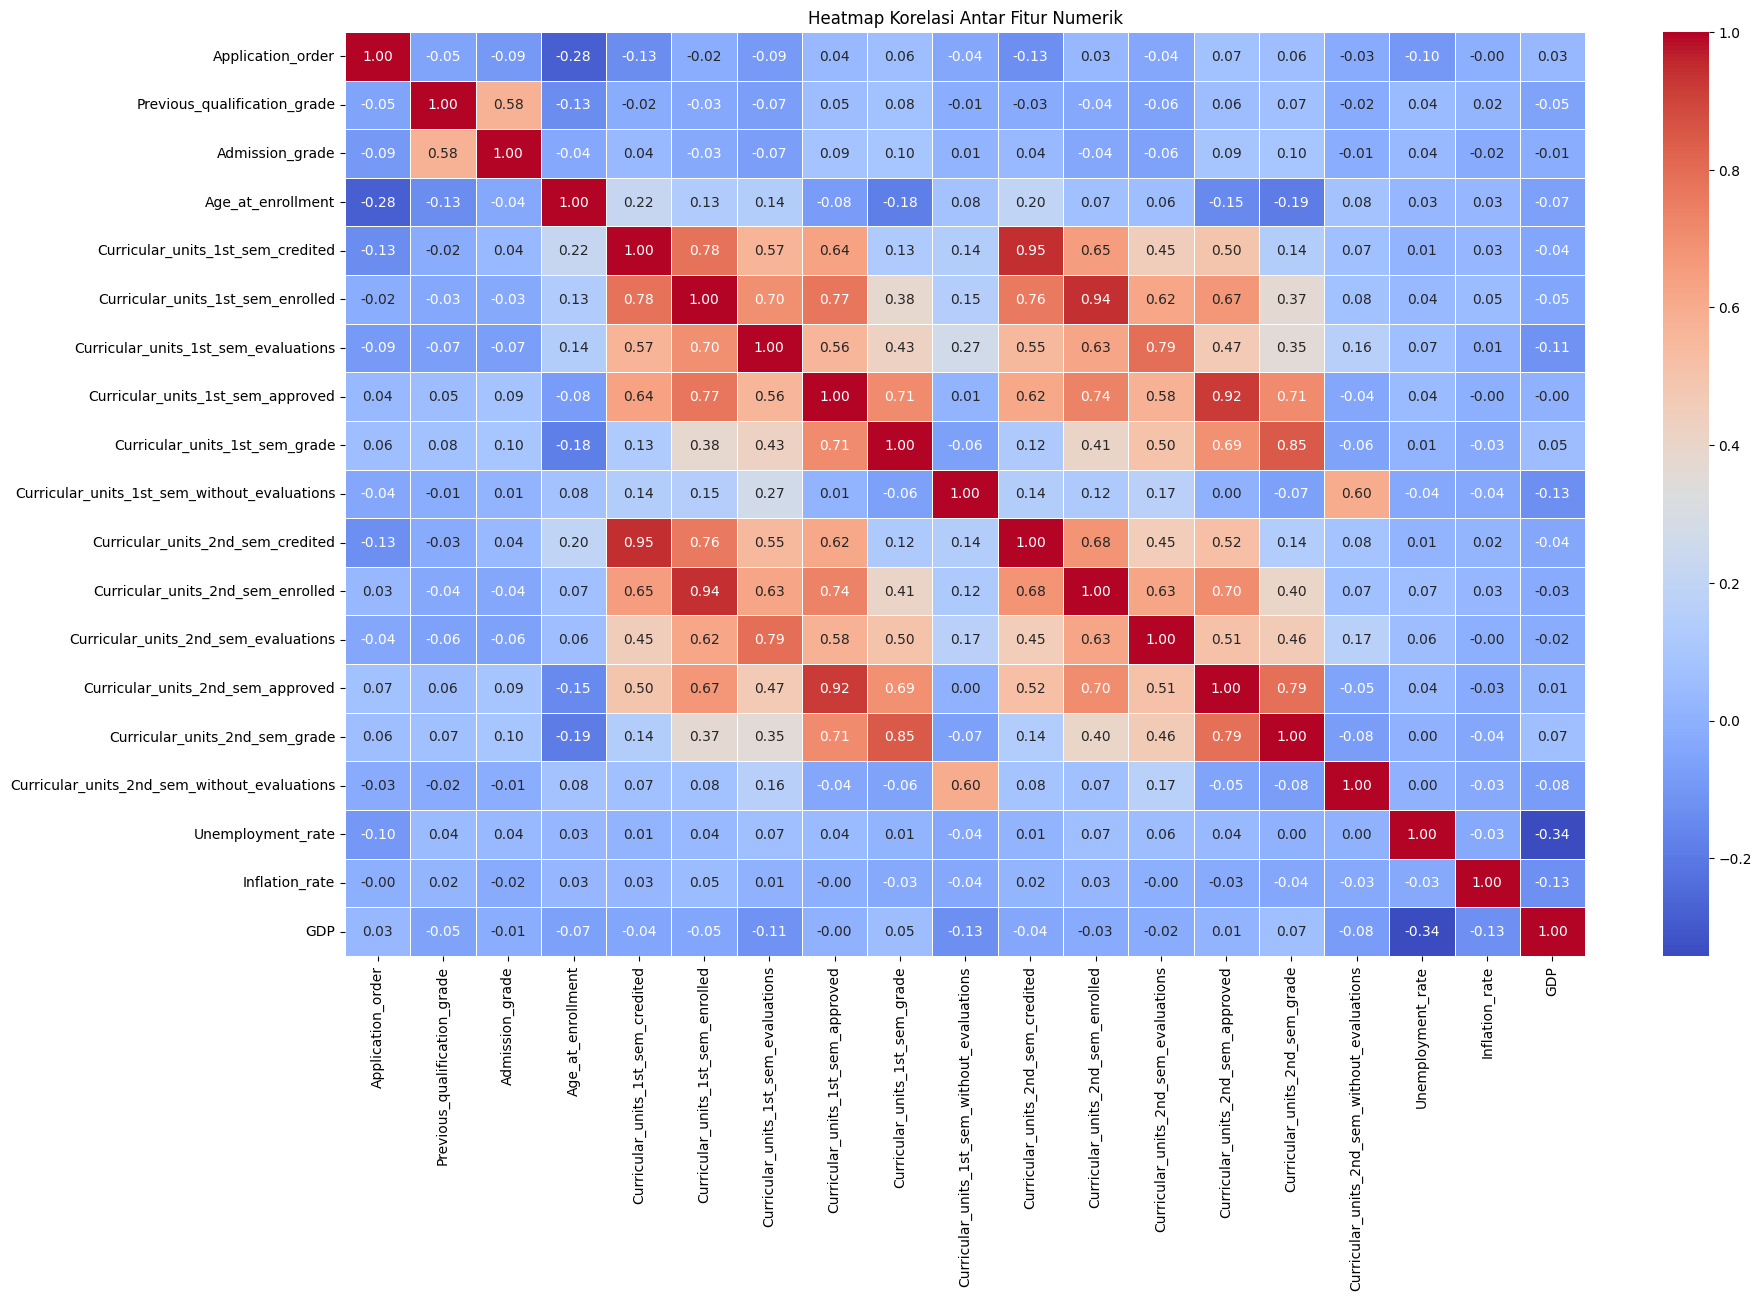

In [234]:
# Plot heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur Numerik")
plt.show()

In [235]:
print(df[num_cols].skew())

Application_order                               1.817973
Previous_qualification_grade                    0.287623
Admission_grade                                 0.507668
Age_at_enrollment                               1.990725
Curricular_units_1st_sem_credited               4.064552
Curricular_units_1st_sem_enrolled               1.651648
Curricular_units_1st_sem_evaluations            1.146086
Curricular_units_1st_sem_approved               0.754178
Curricular_units_1st_sem_grade                 -1.451853
Curricular_units_1st_sem_without_evaluations    8.719276
Curricular_units_2nd_sem_credited               4.494329
Curricular_units_2nd_sem_enrolled               0.811620
Curricular_units_2nd_sem_evaluations            0.378069
Curricular_units_2nd_sem_approved               0.268199
Curricular_units_2nd_sem_grade                 -1.167812
Curricular_units_2nd_sem_without_evaluations    7.615448
Unemployment_rate                               0.189502
Inflation_rate                 

In [236]:
df_corr = df.copy()
df_corr['Status'] = df_corr['Status'].map({
    'Dropout':0,
    'Graduate':1
})
correlation_matrix = df_corr.corr()

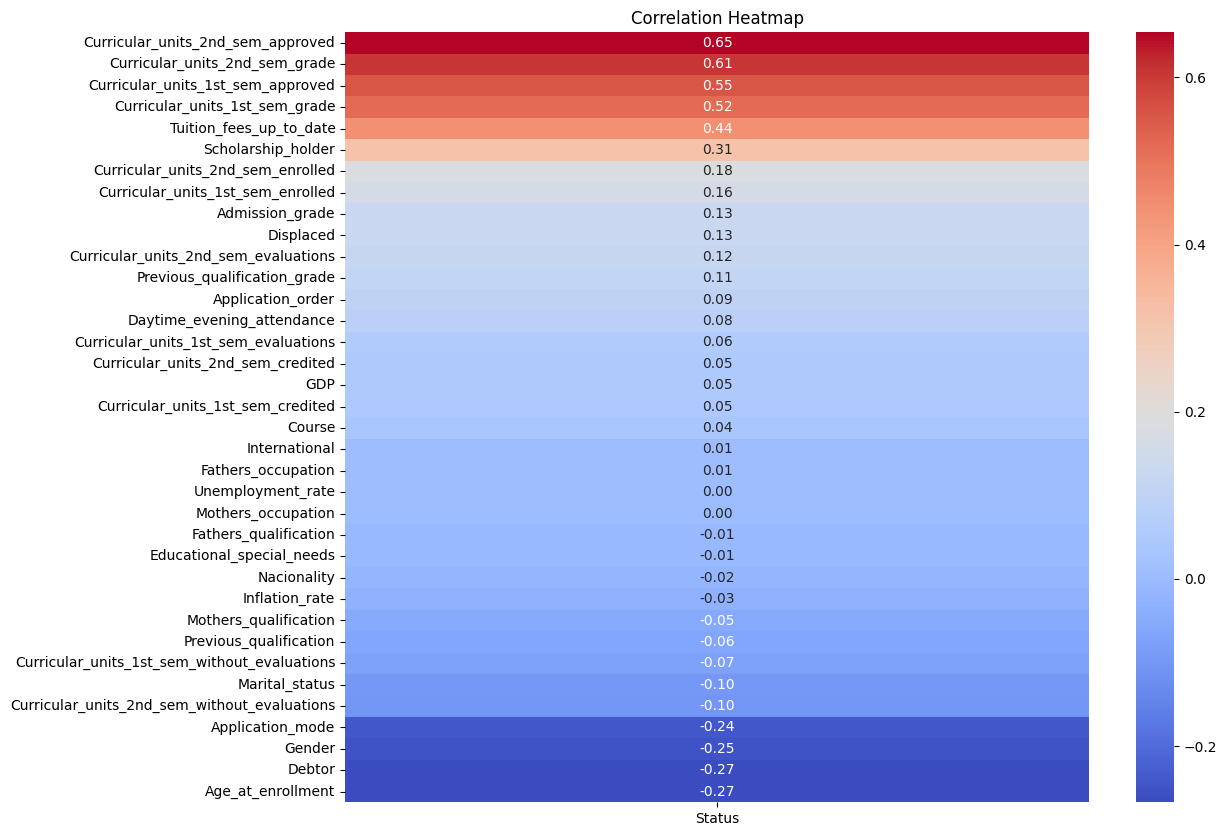

In [237]:
corr_status = correlation_matrix['Status'].sort_values(ascending=False)
corr_status = corr_status.drop('Status') # Buang 'Status' itu sendiri (korelasi dengan dirinya = 1.0)

plt.figure(figsize=(12,10))
sns.heatmap(corr_status.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show() 

In [238]:
df.to_csv('students_performance_cleaned_data.csv', index=False)

## Data Preparation / Preprocessing

In [239]:
# Transformasi (log1p)
df['Curricular_units_1st_sem_without_evaluations'] = np.log1p(df['Curricular_units_1st_sem_without_evaluations'])
df['Curricular_units_2nd_sem_without_evaluations'] = np.log1p(df['Curricular_units_2nd_sem_without_evaluations'])
df['Curricular_units_1st_sem_credited'] = np.log1p(df['Curricular_units_1st_sem_credited'])
df['Curricular_units_2nd_sem_credited'] = np.log1p(df['Curricular_units_2nd_sem_credited'])
print(df[num_cols].skew())

Application_order                               1.817973
Previous_qualification_grade                    0.287623
Admission_grade                                 0.507668
Age_at_enrollment                               1.990725
Curricular_units_1st_sem_credited               2.736838
Curricular_units_1st_sem_enrolled               1.651648
Curricular_units_1st_sem_evaluations            1.146086
Curricular_units_1st_sem_approved               0.754178
Curricular_units_1st_sem_grade                 -1.451853
Curricular_units_1st_sem_without_evaluations    4.875112
Curricular_units_2nd_sem_credited               2.939605
Curricular_units_2nd_sem_enrolled               0.811620
Curricular_units_2nd_sem_evaluations            0.378069
Curricular_units_2nd_sem_approved               0.268199
Curricular_units_2nd_sem_grade                 -1.167812
Curricular_units_2nd_sem_without_evaluations    4.937181
Unemployment_rate                               0.189502
Inflation_rate                 

In [240]:
# Encoding fitur kategorikal
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])
df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0.0,0,0,0,0.000000,0.0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0.0,6,6,6,13.666667,0.0,13.9,-0.3,0.79,1
2,1,1,5,9070,1,1,122.0,1,37,37,...,0.0,6,0,0,0.000000,0.0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0.0,6,10,5,12.400000,0.0,9.4,-0.8,-3.12,1
4,2,39,1,8014,0,1,100.0,1,37,38,...,0.0,6,6,6,13.000000,0.0,13.9,-0.3,0.79,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0.0,6,8,5,12.666667,0.0,15.5,2.8,-4.06,1
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0.0,6,6,2,11.000000,0.0,11.1,0.6,2.02,0
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0.0,8,9,1,13.500000,0.0,13.9,-0.3,0.79,0
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0.0,5,6,5,12.000000,0.0,9.4,-0.8,-3.12,1


In [241]:
# Split dulu sebelum scaling 
X = df.drop('Status', axis=1)
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)


In [242]:
# Ambil 5 fitur dengan korelasi absolut tertinggi
top5_corr_features = corr_status.abs().sort_values(ascending=False).head(5).index.tolist()
top5_corr_features

['Curricular_units_2nd_sem_approved',
 'Curricular_units_2nd_sem_grade',
 'Curricular_units_1st_sem_approved',
 'Curricular_units_1st_sem_grade',
 'Tuition_fees_up_to_date']

In [243]:
# Filter dataset
X_train_selected = X_train[top5_corr_features]
X_test_selected  = X_test[top5_corr_features]

In [244]:
# Fit scaler hanya dari data train (RobustScaler)
scaler = RobustScaler()
# X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
# X_test[num_cols] = scaler.transform(X_test[num_cols])
X_train_selected = pd.DataFrame(scaler.fit_transform(X_train_selected.values), columns=top5_corr_features)
X_test_selected  = pd.DataFrame(scaler.transform(X_test_selected.values), columns=top5_corr_features)

In [245]:
X_train

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
291,1,44,1,9003,1,39,150.0,1,19,37,...,0.000000,0.000000,6,7,6,13.833333,0.000000,13.9,-0.3,0.79
968,2,39,1,9991,0,1,135.0,1,34,34,...,0.000000,0.000000,5,5,0,0.000000,0.000000,7.6,2.6,0.32
785,1,1,1,9238,1,1,121.0,1,1,1,...,0.000000,0.000000,6,7,6,12.142857,0.000000,11.1,0.6,2.02
451,1,1,4,9500,1,1,135.0,1,37,37,...,0.000000,0.000000,8,8,7,13.381429,0.000000,10.8,1.4,1.74
2890,2,39,1,8014,0,12,110.0,1,34,34,...,0.000000,1.098612,6,9,6,12.500000,0.000000,7.6,2.6,0.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3724,1,1,2,9670,1,1,122.0,1,1,1,...,0.000000,0.000000,5,5,5,12.200000,0.000000,9.4,-0.8,-3.12
947,1,17,2,9773,1,1,133.1,1,3,5,...,0.000000,0.000000,4,8,0,0.000000,0.000000,7.6,2.6,0.32
1687,1,7,1,9556,1,3,140.0,1,3,3,...,0.000000,0.000000,5,5,0,0.000000,0.000000,13.9,-0.3,0.79
3988,1,1,1,9085,1,1,123.0,1,19,37,...,1.098612,0.000000,5,10,3,12.000000,0.693147,9.4,-0.8,-3.12


In [246]:
X_test

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
3734,1,43,1,9147,1,1,129.0,1,19,1,...,0.0,1.791759,9,14,7,11.250000,1.098612,12.7,3.7,-1.70
13,1,53,1,9254,1,42,110.0,1,1,1,...,0.0,0.000000,6,8,5,11.000000,0.000000,8.9,1.4,3.51
2182,1,43,1,9500,1,1,140.0,1,19,19,...,0.0,0.000000,8,11,8,13.063636,0.000000,16.2,0.3,-0.92
3939,1,1,5,9500,1,1,118.0,1,3,1,...,0.0,0.000000,8,8,8,15.012500,0.000000,12.4,0.5,1.79
2054,1,1,2,9556,1,1,142.0,1,1,19,...,0.0,0.000000,8,8,8,14.062500,0.000000,16.2,0.3,-0.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,1,1,1,9238,1,1,125.0,1,1,1,...,0.0,0.000000,6,8,6,12.333333,0.000000,12.4,0.5,1.79
4410,1,1,1,9070,1,1,124.0,1,37,19,...,0.0,0.693147,6,9,5,12.500000,0.000000,10.8,1.4,1.74
630,1,39,1,9500,1,1,133.1,1,19,37,...,0.0,0.000000,8,8,7,12.042857,0.000000,12.7,3.7,-1.70
688,3,39,1,9991,0,1,120.0,1,37,1,...,0.0,0.000000,5,6,5,14.000000,0.000000,9.4,-0.8,-3.12


In [247]:
df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0.0,0,0,0,0.000000,0.0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0.0,6,6,6,13.666667,0.0,13.9,-0.3,0.79,1
2,1,1,5,9070,1,1,122.0,1,37,37,...,0.0,6,0,0,0.000000,0.0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0.0,6,10,5,12.400000,0.0,9.4,-0.8,-3.12,1
4,2,39,1,8014,0,1,100.0,1,37,38,...,0.0,6,6,6,13.000000,0.0,13.9,-0.3,0.79,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0.0,6,8,5,12.666667,0.0,15.5,2.8,-4.06,1
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0.0,6,6,2,11.000000,0.0,11.1,0.6,2.02,0
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0.0,8,9,1,13.500000,0.0,13.9,-0.3,0.79,0
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0.0,5,6,5,12.000000,0.0,9.4,-0.8,-3.12,1


Menggunakan **.abs()** karena korelasi negatif juga berarti hubungan yang kuat — misalnya jika Curricular_units_2nd_sem_without_evaluations memiliki korelasi -0.35, itu tetap lebih informatif dibanding fitur lain yang korelasinya +0.02. Tanpa .abs(), fitur dengan korelasi negatif kuat bisa terlewat.

## Modeling

In [248]:
print(df['Status'].value_counts())

Status
1    2209
0    1421
Name: count, dtype: int64


In [249]:
print(df['Status'].value_counts(normalize=True) * 100)

Status
1    60.853994
0    39.146006
Name: proportion, dtype: float64


In [250]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# smote = SMOTE(random_state=42)
# X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

### Random Forest

In [251]:
# Model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=7,             
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

# training model Random Forest 
rf_model.fit(X_train_selected, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### XGBClassifier

In [252]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,        # gunakan 80% data per pohon
    colsample_bytree=0.8, # gunakan 80% fitur per pohon
    reg_alpha=0.1,        # L1 regularization
    reg_lambda=1.0,       # L2 regularization
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_selected, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Evaluation

### Random Forest

In [253]:
# Prediksi di data training
y_train_pred_rf = rf_model.predict(X_train_selected)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print(classification_report(y_train, y_train_pred_rf))

Training Accuracy: 0.900137741046832
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1137
           1       0.90      0.93      0.92      1767

    accuracy                           0.90      2904
   macro avg       0.90      0.89      0.89      2904
weighted avg       0.90      0.90      0.90      2904



In [254]:
# Prediksi di data testing
y_test_pred_rf = rf_model.predict(X_test_selected)

print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print(classification_report(y_test, y_test_pred_rf))

Testing Accuracy: 0.8856749311294766
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       284
           1       0.89      0.92      0.91       442

    accuracy                           0.89       726
   macro avg       0.88      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



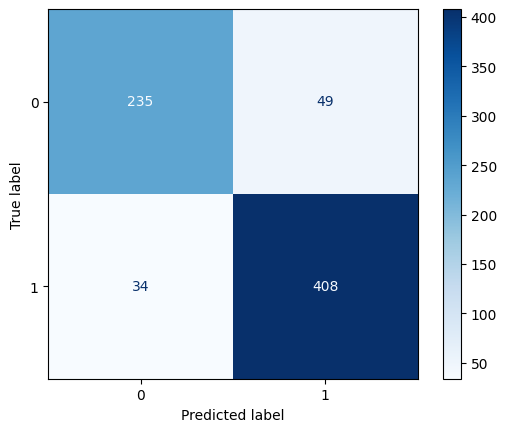

In [255]:
cm = confusion_matrix(y_test, y_test_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

### XGBClassifier

In [256]:
# Prediksi di data training
y_train_pred_rf = xgb_model.predict(X_train_selected)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print(classification_report(y_train, y_train_pred_rf))

Training Accuracy: 0.8963498622589532
              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1137
           1       0.91      0.92      0.92      1767

    accuracy                           0.90      2904
   macro avg       0.89      0.89      0.89      2904
weighted avg       0.90      0.90      0.90      2904



In [257]:
# Prediksi di data testing
y_test_pred_rf = xgb_model.predict(X_test_selected)

print("Testing Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print(classification_report(y_test, y_test_pred_rf))

Testing Accuracy: 0.8856749311294766
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       284
           1       0.90      0.92      0.91       442

    accuracy                           0.89       726
   macro avg       0.88      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726



Curricular_units_2nd_sem_approved    0.431061
Curricular_units_1st_sem_approved    0.240946
Curricular_units_2nd_sem_grade       0.164598
Tuition_fees_up_to_date              0.084900
Curricular_units_1st_sem_grade       0.078494
dtype: float64


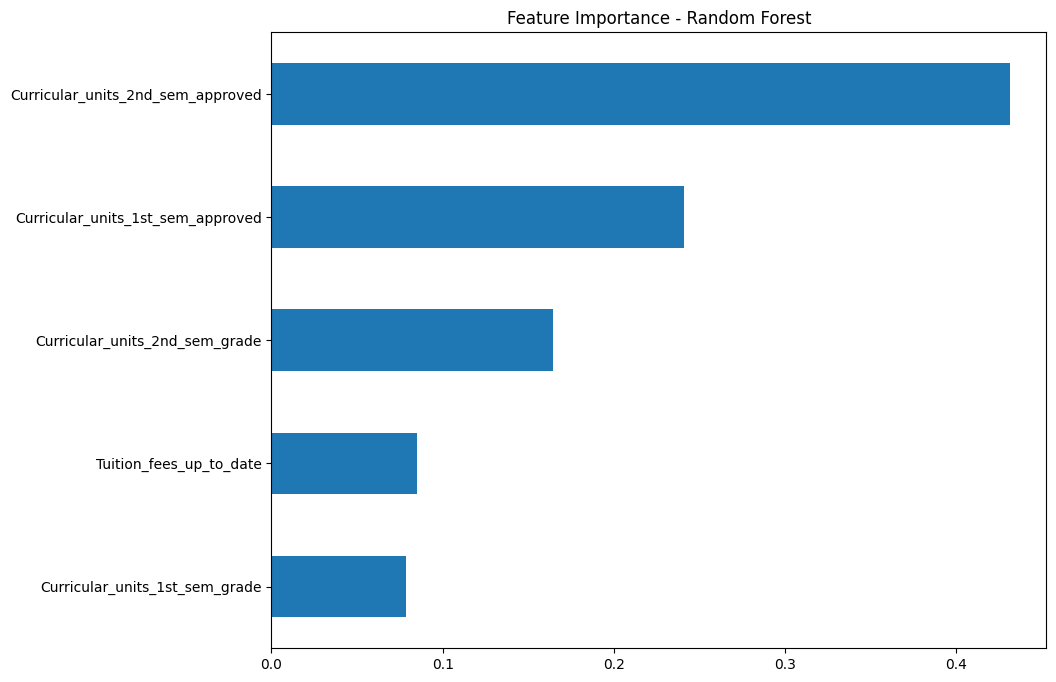

In [259]:
feat_imp = pd.Series(
    rf_model.feature_importances_, 
    index=X_train_selected.columns
).sort_values(ascending=False)

print(feat_imp)

feat_imp.plot(kind='barh', figsize=(10, 8))
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [260]:
# Simpan model Random Forest
os.makedirs("model", exist_ok=True)
joblib.dump(rf_model, "../venv/model/rf_model.pkl")

['../venv/model/rf_model.pkl']

In [261]:
# Simpan model XGBClassifier
os.makedirs("model", exist_ok=True)
joblib.dump(xgb_model, "../venv/model/xgb_model.pkl")

['../venv/model/xgb_model.pkl']

In [262]:
# Simpan scaler
joblib.dump(scaler, '../venv/scaler/robust_scaler.pkl')

['../venv/scaler/robust_scaler.pkl']